In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2026

@author: Carles-Bou
"""
#!git clone https://github.com/CarlesBou/mlpxai.git
#!cd mlpxai/src/examples/notebooks

'''
Adjust import paths if needed
'''
import os
import sys

#print(os.getcwd())

sys.path.insert(0, os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.insert(0, os.path.dirname(os.getcwd()))

In [2]:
'''
Import libraries
'''
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

from damero_dataset import get_damero_dataset
from damero_model   import get_damero_model 

from utils.face_torch  import FNNModule
from utils.face_torch  import count_configurations
from utils.set_random  import set_random_seed
from utils.graph       import ImplicitEquationPlotter
from utils.gface_torch import get_rules
from utils.print_texts import print_bold, get_config_structure

In [3]:
'''
Set model ininitalization variables
'''
num_inputs = 2
num_outputs = 2
   
hidden_struct=[4,4]
epochs=20000 
lr=0.001
random_seed=13112
normalized_range = ([0.0, 1.0], [0.0, 1.0])

# Set seed for random number generators
set_random_seed(random_seed)

In [4]:
'''
Load Damero dataset (generate it if it does not exist)
'''
X_train, y_train_categorical, y_train, \
    X_test, y_test_categorical, y_test = get_damero_dataset(num_inputs, random_seed) 

train_dataset = TensorDataset(X_train, y_train_categorical)
train_loader = DataLoader(train_dataset, batch_size=32)

In [5]:
'''
Load Model (generate it if it does not exist)
'''
model = get_damero_model(num_inputs, num_outputs, hidden_struct, \
                         epochs, random_seed, lr, \
                         X_train, y_train, train_loader)

Using pretrained classification model weights from file models/damero_inputs_2_hidden_[4, 4]_epochs_20000_seed_13112_lr_0.001.pth


In [6]:
'''
Get model accuracy for test dataset
'''
print('Generating predictions for test data ... ', end='')

mlp_predictions = model(X_test).detach().numpy()
y_mlp = np.argmax(mlp_predictions, axis=1)

print('OK')

test_accuracy = np.sum(y_mlp == y_test) / len(y_test)

print(f'Test data accuracy = {test_accuracy:.5f}\n')

Generating predictions for test data ... OK
Test data accuracy = 0.98370



In [7]:
'''
Get configurations (activation patterns) for train dataset
'''
configs, config_samples, color_count = count_configurations(model, X_train, y_train)

activation_patterns = list(map(lambda x: get_config_structure([4, 4], x), configs.keys()))

print(f'#Activation Patterns: {len(activation_patterns)}\n')

print(f'Activation Patterns = {activation_patterns}\n')

#Activation Patterns: 6

Activation Patterns = ['0001-0011', '1001-0011', '1011-0000', '1011-0010', '1011-0011', '1011-0100']



In [8]:
'''
Get rules for specific config (activation pattern)
'''
config = '1011-0010'
# config = '10110100'
# config = '00010011'

print_bold(f'Rules for Activation Pattern [{config}]\n')


rule_texts = get_rules(model, X_train, y_train, 
                       normalized_range,
                       config_samples, config)

print_bold(rule_texts['rule_antecedents'][0])
print(rule_texts['rule_antecedents'][1])

print_bold(rule_texts['rule_consequent'][0])
print(rule_texts['rule_consequent'][1])

print_bold(rule_texts['activation_region'][0])
print(rule_texts['activation_region'][1])

 Class R (red)
  x2  >= 0
  x1 - 1.0000 <= 0
  x1 - 0.9694x2 - 0.1876 <= 0
  x1 - 0.9789x2 - 0.0246 >= 0

 Class G (green)
  x2  >= 0
  x1 - 1.0000 <= 0
  x1 - 0.9694x2 - 0.3102 <= 0
  x1 - 0.9694x2 - 0.1876 >= 0



  Y_r = -74.1621x1 + 71.8930x2 + 13.9084
  Y_g = 74.0997x1 - 71.8325x2 - 13.8981



  x2  >= 0
  x1 - 1.0000 <= 0
  x1 - 0.9694x2 - 0.3102 <= 0
  x1 - 0.9789x2 - 0.0246 >= 0



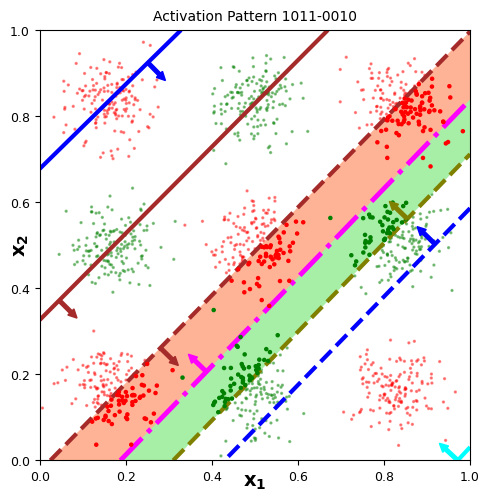

In [9]:
'''
Plot config (activation pattern)
'''

plotter_options = {
    'configs': configs,
    'config_samples': config_samples, 
    'X': X_train, 
    'y': y_train, 
    'model': model,
    'normalized_range': normalized_range,
    # 'point_size': 1.5,
    # 'light_point_size': 1.5,
    # 'light_point_alpha': 0.5,
    # 'class_linewidth': 2,
    # 'neuron_linewidth': 1.6,
    'class_linewidth': 3.5,
    'neuron_linewidth': 3,
    'hidden_struct': hidden_struct,
    'arrow_length': 0.35,
    'arrow_head_size': 0.12,
}
    

plotter = ImplicitEquationPlotter(**plotter_options)

plotter.show(config)